In [9]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum

import training_runtime 
import inference_runtime


In [10]:
MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "batch_size"  : 2**4,   # 16
    "vocab_size"  : 2**11,  # 2048
    "learning_rate" : 1e-3,
    "save_path" : "../models/level1_bigram_weights.pt",
    "loss_history" : "../models/level1_loss_history.txt",
}

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [12]:
# define model arch

class Level1BigramLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)



    def forward(self, idx: torch.Tensor)-> torch.Tensor:

        batch_size, seq_len = idx.shape 

        # 1. Embedding Lookup: Retrieve vector representations
        x = self.embed[idx]

        # 2. Unembedding Projection: Project directly to vocabulary
        logits = einsum(x, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")

        return logits


Step 0000 | Batch Loss: 7.6246 nats
Step 0005 | Batch Loss: 7.6242 nats
Step 0010 | Batch Loss: 7.6240 nats
Step 0015 | Batch Loss: 7.6239 nats
Step 0020 | Batch Loss: 7.6235 nats
Step 0025 | Batch Loss: 7.6231 nats
Step 0030 | Batch Loss: 7.6229 nats
Step 0035 | Batch Loss: 7.6214 nats
Step 0040 | Batch Loss: 7.6212 nats
Step 0045 | Batch Loss: 7.6202 nats
Step 0050 | Batch Loss: 7.6187 nats
Step 0055 | Batch Loss: 7.6186 nats
Step 0060 | Batch Loss: 7.6169 nats
Step 0065 | Batch Loss: 7.6139 nats
Step 0070 | Batch Loss: 7.6117 nats
Step 0075 | Batch Loss: 7.6102 nats
Step 0080 | Batch Loss: 7.6075 nats
Step 0085 | Batch Loss: 7.6070 nats
Step 0090 | Batch Loss: 7.5979 nats
Step 0095 | Batch Loss: 7.5942 nats
Step 0099 | Batch Loss: 7.5884 nats

Saving model weights to: ../models/level1_bigram_weights.pt
Loss history successfully saved to ../models/level1_loss_history.txt
Loaded 100 steps from ../models/level1_loss_history.txt


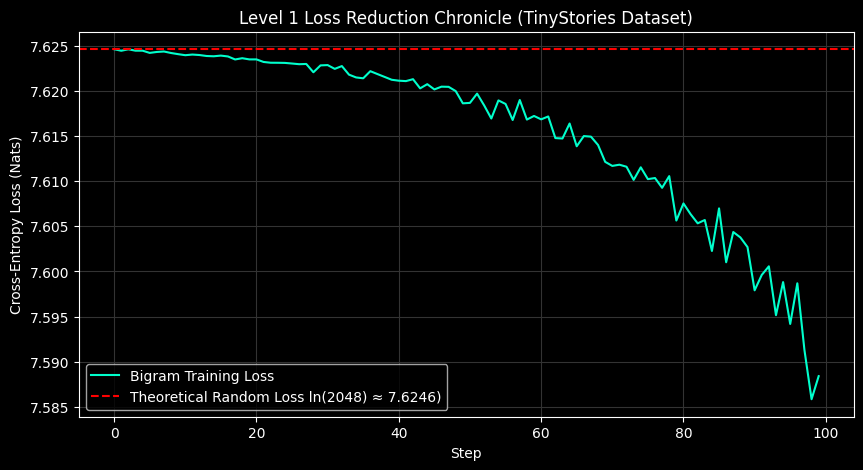

In [13]:

model = Level1BigramLM()
configs = MODEL_CONFIGS

# trains and plots loss curves

training_runtime.train_and_save_model(model, configs, device, 100)
training_runtime.plot_loss_history(configs)


In [15]:
# autoregressive inference, no KV cache handling

from tokenizerModule import Tokenizer

def inference(num_gen_steps:int, prompt:str, temperature:float) -> str:

    if num_gen_steps < 0:
        raise ValueError("num_gen_steps must be non-negative")


    input_tokens = Tokenizer.encode(prompt)


    # handle empty prompt
    if len(input_tokens) == 0:
        raise ValueError("Prompt produced no tokens. Provide a non-empty prompt.")


    # list to progressively append our generated predictions
    # clip long prompts to the training context window
    generated_tokens = list(input_tokens[-MODEL_CONFIGS["max_seq_len"] :])

    print("\n--- Autoregressive Generation ---")
    print(f"Prompt: '{prompt}'")
    print(f"Tokenized Input: {input_tokens}")
    print(f"Context Used: {generated_tokens}")


    # (No-gradient environment)
    fresh_model.eval() 
    with torch.no_grad():
        for step in range(num_gen_steps):

            # truncate the input to the last "max_seq_len" tokens
            context_window = generated_tokens[-MODEL_CONFIGS["max_seq_len"] :]
            
            # Convert current tokens to a PyTorch tensor (batch_size=1, seq_len=len(generated_tokens))
            input_tensor = torch.tensor([context_window], device=device, dtype=torch.long)

            # Model forward pass 
            # (batch_size=1, seq_len=len(generated_tokens), vocab_size=MODEL_CONFIGS["vocab_size"])
            logits = fresh_model(input_tensor)

            # Extract the logits for ONLY the final token position in the sequence
            last_logits = rearrange(logits[:, -1, :], "1 vocab_size -> vocab_size")

            # temperature controls the sharpness of the distribution
            tempered_logits = last_logits / max(temperature, 1e-6)

            # Convert to probability distribution
            probabilities = torch.softmax(tempered_logits, dim=-1)

            # Multinomial Sampling
            next_token_tensor = torch.multinomial(probabilities, num_samples=1)
            next_token = next_token_tensor.item()

            # Append predicted token to sequence for the next autoregressive loop step
            generated_tokens.append(next_token)

    return Tokenizer.decode(generated_tokens)


inference(45, "Once upon a time, there was an", temperature=1.0)


--- Autoregressive Generation ---
Prompt: 'Once upon a time, there was an'
Tokenized Input: [292, 244, 198, 398]
Context Used: [292, 244, 198, 398]


NameError: name 'fresh_model' is not defined

In [8]:
# inference

prompt = "write a story about"

model_scaffold = Level1BigramLM()
inference_runtime.inference(model_scaffold, configs, device, prompt, 100)


TypeError: inference() takes 4 positional arguments but 5 were given